In [1]:
# 통계논문 - CTR 분석 노트북
# 아래 셀들을 순서대로 실행해 주세요. (Google Colab 사용 시 먼저 Drive 마운트)

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # 로컬 Jupyter / VS Code


**Google Colab 사용 시:**  
Drive 마운트 후 `static_document_dataset.zip` 파일 경로를 확인하고, 다음 셀의 `ZIP_FILE_PATH` 변수를 해당 경로로 수정한 뒤 압축 해제 셀을 실행해 주세요.

In [3]:
import pandas as pd
from pathlib import Path

def _find_sample_submission() -> Path:
    for root in (Path.cwd(), Path.cwd().parent):
        p = root / "data" / "sample_submission.csv"
        if p.exists():
            return p
    return Path("static_document_dataset/sample_submission.csv")

sample = pd.read_csv(_find_sample_submission())


In [4]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

# 메모리 부족을 피하기 위해 기본은 샘플 행만 로드합니다.
# 전체 로드가 필요하면 n_rows=None으로 변경하세요.
def load_parquet_safely(path, n_rows=50_000, batch_size=50_000):  # 논문 개발 중 빠른 실행용. 전체: n_rows=None
    if n_rows is None:
        return pd.read_parquet(path, engine="pyarrow")

    parquet_file = pq.ParquetFile(path)
    batches = []
    loaded = 0

    for batch in parquet_file.iter_batches(batch_size=batch_size):
        batch_df = batch.to_pandas(types_mapper=pd.ArrowDtype)
        batches.append(batch_df)
        loaded += len(batch_df)
        if loaded >= n_rows:
            break

    if not batches:
        return pd.DataFrame()

    result = pd.concat(batches, ignore_index=True)
    return result.iloc[:n_rows].copy()

# data/ 또는 Colab 경로에서 로드 (로컬: train_sample.parquet 사용)
from pathlib import Path

def _data_dir() -> Path:
    for root in (Path.cwd(), Path.cwd().parent):
        d = root / "data"
        if (d / "train_sample.parquet").exists() or (d / "train.parquet").exists():
            return d
    return Path("/content/static_document_dataset")

_dd = _data_dir()
_train_p = _dd / "train.parquet" if (_dd / "train.parquet").exists() else _dd / "train_sample.parquet"
_test_p = _dd / "test.parquet" if (_dd / "test.parquet").exists() else _train_p
train = load_parquet_safely(str(_train_p), n_rows=200_000)
test = load_parquet_safely(str(_test_p), n_rows=200_000)

print(f"train shape (sample): {train.shape}")
print(f"test shape (sample): {test.shape}")

train shape (sample): (200000, 119)
test shape (sample): (200000, 119)


In [5]:
import matplotlib.pyplot as plt

# Korean font settings removed as English is requested
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

# train_sample: train 데이터프레임 (train_sample.parquet에서 로드)
train_sample = train

# click 컬럼 확인
if 'click' not in train_sample.columns:
    print("Available columns:", train_sample.columns.tolist()[:20], "...")
    # Alternative: label, target, etc.
    click_col = next((c for c in ['click', 'label', 'target', 'is_click', 'clicked'] if c in train_sample.columns), None)
else:
    click_col = 'click'

if click_col:
    click_series = train_sample[click_col]
    print("=== Basic Statistics of click variable ===")
    print(click_series.value_counts().sort_index())
    print(f"\nCTR (Click-Through Rate): {click_series.mean():.4%}")
    print(f"Click Ratio: {(click_series == 1).sum():,} / {len(click_series):,}")
else:
    raise KeyError("Could not find a click-related column.")

Available columns: ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14'] ...
=== Basic Statistics of click variable ===
clicked
0    196041
1      3959
Name: count, dtype: int64[pyarrow]

CTR (Click-Through Rate): 1.9795%
Click Ratio: 3,959 / 200,000


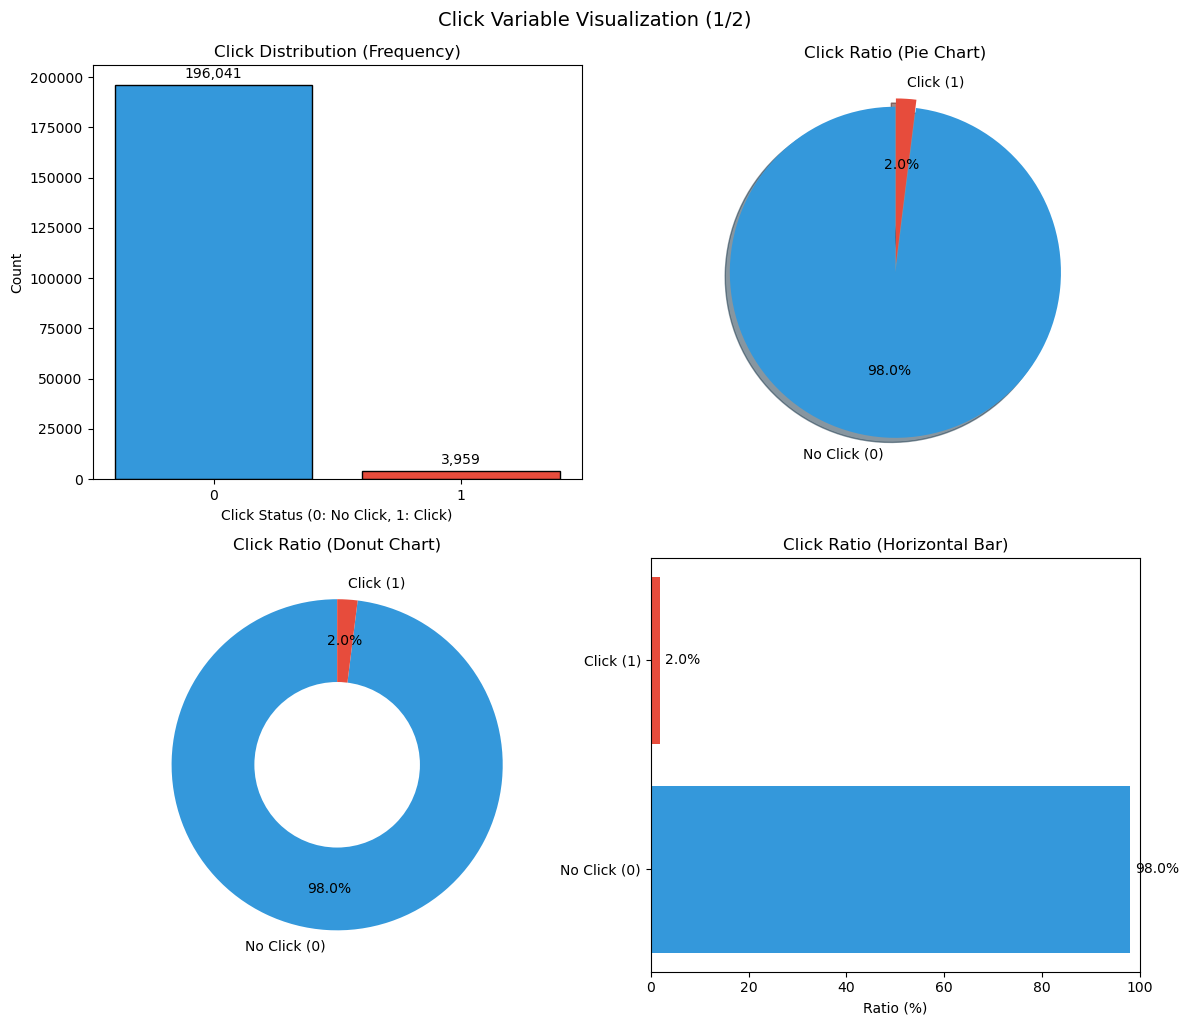

In [6]:
# 1. Bar chart: Click (1) vs. No-click (0) frequency
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1-1. Frequency bar chart
counts = click_series.value_counts().sort_index()
ax1 = axes[0, 0]
bars = ax1.bar(counts.index.astype(str), counts.values, color=['#3498db', '#e74c3c'], edgecolor='black')
ax1.set_title('Click Distribution (Frequency)', fontsize=12)
ax1.set_xlabel('Click Status (0: No Click, 1: Click)')
ax1.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{val:,}', ha='center', va='bottom', fontsize=10)

# 1-2. Pie chart: Ratio
ax2 = axes[0, 1]
labels = ['No Click (0)', 'Click (1)']
sizes = [counts.get(0, 0), counts.get(1, 0)]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.05)
ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax2.set_title('Click Ratio (Pie Chart)', fontsize=12)

# 2. Donut chart
ax3 = axes[1, 0]
wedges, texts, autotexts = ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                    startangle=90, pctdistance=0.75)
centre_circle = plt.Circle((0, 0), 0.5, fc='white')
ax3.add_artist(centre_circle)
ax3.set_title('Click Ratio (Donut Chart)', fontsize=12)

# 3. Horizontal bar (Ratio)
ax4 = axes[1, 1]
pcts = [sizes[0]/sum(sizes)*100, sizes[1]/sum(sizes)*100]
bars = ax4.barh(labels, pcts, color=colors)
ax4.set_xlabel('Ratio (%)')
ax4.set_title('Click Ratio (Horizontal Bar)', fontsize=12)
ax4.set_xlim(0, 100)
for bar, pct in zip(bars, pcts):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Click Variable Visualization (1/2)', fontsize=14, y=1.02)
plt.show()

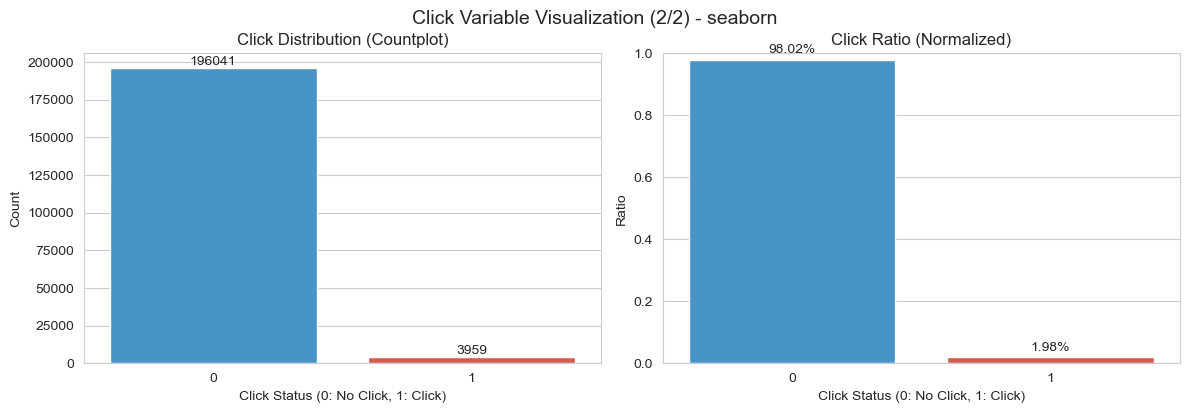

In [7]:
# 2. seaborn based visualization
try:
    import seaborn as sns
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Convert `clicked` column to standard int type to avoid `ArrowNotImplementedError`
    # This resolves compatibility issues seaborn might have with pyarrow types.
    train_sample_plot = train_sample.copy()
    train_sample_plot[click_col] = train_sample_plot[click_col].astype(int)

    # 2-1. countplot
    ax1 = axes[0]
    sns.countplot(data=train_sample_plot, x=click_col, hue=click_col, palette={0: '#3498db', 1: '#e74c3c'}, ax=ax1, legend=False)
    ax1.set_title('Click Distribution (Countplot)', fontsize=12)
    ax1.set_xlabel('Click Status (0: No Click, 1: Click)')
    ax1.set_ylabel('Count')
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%d')

    # 2-2. Ratio bar (normalize)
    ax2 = axes[1]
    dist = train_sample_plot[click_col].value_counts(normalize=True).sort_index()
    # Fix FutureWarning: Pass `palette` with `hue` or set `x` to `hue`
    sns.barplot(x=dist.index, y=dist.values, hue=dist.index, palette=['#3498db', '#e74c3c'], ax=ax2, legend=False)
    ax2.set_title('Click Ratio (Normalized)', fontsize=12)
    ax2.set_xlabel('Click Status (0: No Click, 1: Click)')
    ax2.set_ylabel('Ratio')
    ax2.set_ylim(0, 1)
    for i, (idx, val) in enumerate(dist.items()):
        ax2.text(i, val + 0.02, f'{val:.2%}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.suptitle('Click Variable Visualization (2/2) - seaborn', fontsize=14, y=1.02)
    plt.show()
except ImportError:
    print("Seaborn is not installed. Please install it using 'pip install seaborn' and rerun.")

- ✅ CTR 1.98% (불균형 데이터)로 기본 통계 및 다중 시각화 완료
- 🔍 추가 EDA: gender×age, day×hour별 CTR 및 상관관계/이상치 분석 예정
- 🧩 피처 엔지니어링: 시간대·주중여부·상호작용 피처 생성 계획
- 🤖 모델링: Logistic→LightGBM/XGBoost 등과 불균형 처리 수행 예정
- 🎯 목표: 피처별 CTR 히트맵·상관관계 분석 완료 후 AUC 0.75+ 달성

In [8]:
# === CTR 시각화 완료. 다음: 사용자 특성별 CTR 분석 ===

# Task: CTR 종합 분석

사용자 특성(성별, 연령대) 및 시간적 요인(시간대, 요일)에 기반한 클릭률(CTR) 분석을 수행합니다.  
시간 기반 피처 엔지니어링(예: hour→시간대, day_of_week→평일/주말), 상관관계 히트맵 분석, `train.parquet`를 이용한 베이스라인 로지스틱 회귀 모델 구현 및 불균형 데이터에 적합한 지표로 성능 평가를 진행합니다.

## 사용자 특성별 CTR 분석

### 목표
성별(gender) 및 연령대(age_group)에 따른 클릭률(CTR) 분포를 분석합니다. 각 사용자 특성 그룹별 CTR을 계산하고 시각화하여 주요 인사이트를 도출합니다.


### 접근 방법
`train_sample` DataFrame에서 'gender'와 'age_group'별 Click-Through Rate(CTR)를 계산합니다. 클릭 여부를 나타내는 'clicked' 컬럼(1: 클릭, 0: 비클릭)을 사용하여 각 그룹별 평균을 산출합니다.



CTR by Gender:
  gender       CTR
0    1.0  0.019840
1    2.0  0.019793

CTR by Age Group:
  age_group       CTR
0       1.0  0.046332
1       2.0  0.023241
2       3.0  0.020662
3       4.0  0.019665
4       5.0  0.019530
5       6.0  0.015992
6       7.0  0.018507
7       8.0  0.024046


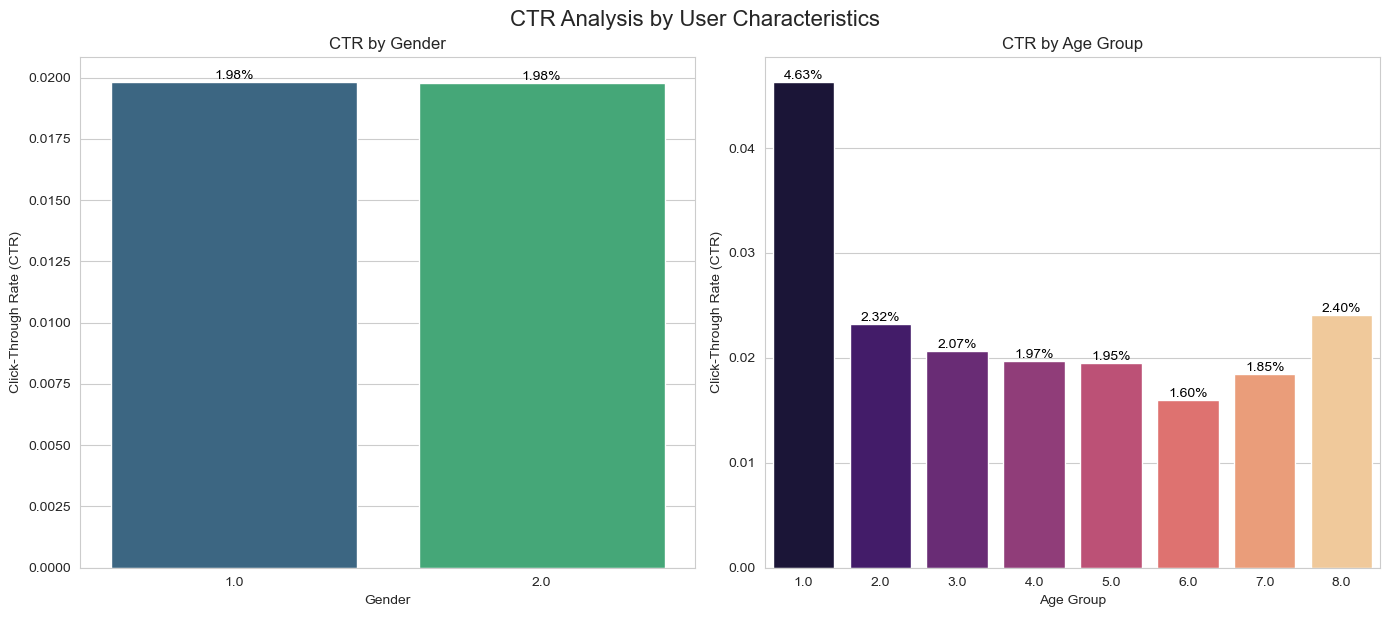

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure 'clicked' column is int for consistent calculations if it's still ArrowDtype
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Calculate CTR by gender
gender_ctr = train_sample_processed.groupby('gender')['clicked'].mean().reset_index()
gender_ctr.columns = ['gender', 'CTR']

# 2. Calculate CTR by age_group
age_group_ctr = train_sample_processed.groupby('age_group')['clicked'].mean().reset_index()
age_group_ctr.columns = ['age_group', 'CTR']

print("CTR by Gender:")
print(gender_ctr)
print("\nCTR by Age Group:")
print(age_group_ctr)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3. Plot Gender CTR
sns.barplot(x='gender', y='CTR', data=gender_ctr, hue='gender', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('CTR by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Click-Through Rate (CTR)')
for index, row in gender_ctr.iterrows():
    axes[0].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 4. Plot Age Group CTR
sns.barplot(x='age_group', y='CTR', data=age_group_ctr, hue='age_group', palette='magma', ax=axes[1], legend=False)
axes[1].set_title('CTR by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in age_group_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 5. Display plots
plt.tight_layout()
plt.suptitle('CTR Analysis by User Characteristics', y=1.02, fontsize=16)
plt.show()


RQ1: Age Group vs CTR — Statistical Tests
One-way ANOVA:   F=15.4916, p=0.000000 ***
Kruskal-Wallis:  H=108.3858, p=0.000000 ***
Effect size eta2=0.000543  (small(<0.06) — Cohen 1988)

Tukey HSD post-hoc (age_group):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  -0.0231  0.007 -0.0424 -0.0038   True
   1.0    3.0  -0.0257 0.0012 -0.0448 -0.0066   True
   1.0    4.0  -0.0267 0.0006 -0.0457 -0.0076   True
   1.0    5.0  -0.0268 0.0005 -0.0458 -0.0078   True
   1.0    6.0  -0.0303    0.0  -0.049 -0.0117   True
   1.0    7.0  -0.0278 0.0002 -0.0465 -0.0092   True
   1.0    8.0  -0.0223 0.0071 -0.0409 -0.0036   True
   2.0    3.0  -0.0026 0.9537 -0.0096  0.0044  False
   2.0    4.0  -0.0036 0.7569 -0.0104  0.0032  False
   2.0    5.0  -0.0037 0.7014 -0.0104   0.003  False
   2.0    6.0  -0.0072  0.003  -0.013 -0.0015   True
   2.0    7.0  -0.0047 0.1637 -0.0103  0.

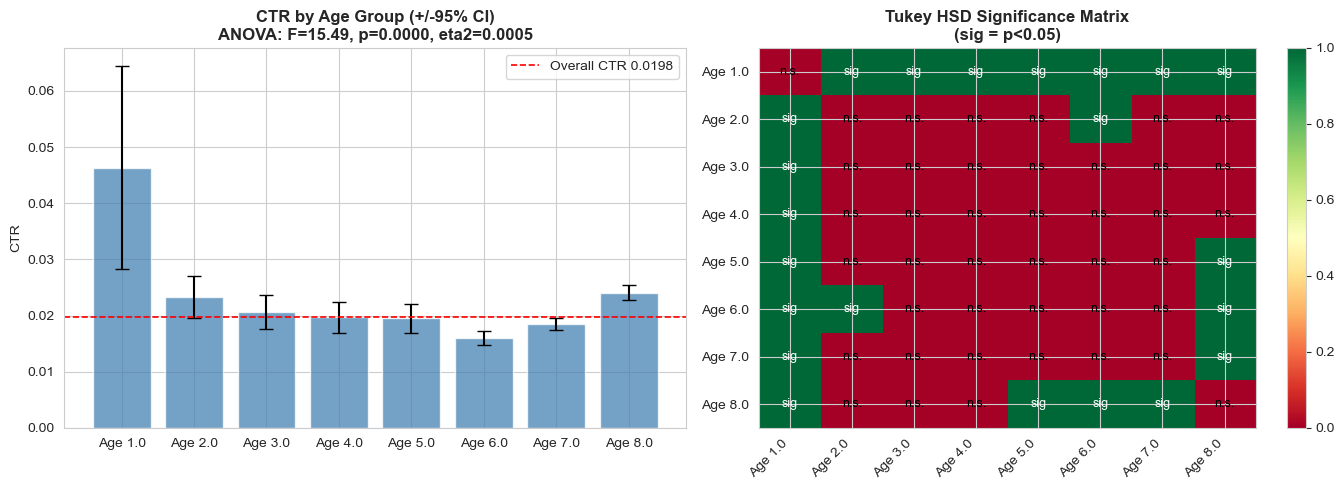


Conclusion: Age group CTR differences are statistically significant (p<0.001)
Practical effect size eta2=0.0005 — small (limited practical significance)
Gender effect Cramer's V=0.0001 — negligible


In [10]:
# ================================================================
# Statistical Tests — User Characteristics (Age Group & Gender)
# Effect size: eta-squared (ANOVA), Cramer's V (Chi-Square)
# ================================================================
from scipy.stats import f_oneway, kruskal, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GLOBAL_CTR_STAT = train_sample_processed['clicked'].mean()

# ── Age Group: One-way ANOVA + Kruskal-Wallis + eta-squared ─────
age_groups_list = sorted(train_sample_processed['age_group'].dropna().unique())
age_samples_stat = [
    train_sample_processed[train_sample_processed['age_group'] == ag]['clicked'].values
    for ag in age_groups_list
]
F_age_stat, p_anova_age_stat = f_oneway(*age_samples_stat)
H_age_stat, p_kruskal_age_stat = kruskal(*age_samples_stat)

# eta^2 = SS_between / SS_total
grand_mean_stat = GLOBAL_CTR_STAT
ss_total_stat = ((train_sample_processed['clicked'] - grand_mean_stat) ** 2).sum()
ss_between_age = sum(len(s) * (s.mean() - grand_mean_stat) ** 2 for s in age_samples_stat if len(s) > 0)
eta_sq_age = ss_between_age / ss_total_stat

print("=" * 60)
print("RQ1: Age Group vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA:   F={F_age_stat:.4f}, p={p_anova_age_stat:.6f} "
      f"{'***' if p_anova_age_stat<0.001 else '**' if p_anova_age_stat<0.01 else '*' if p_anova_age_stat<0.05 else 'n.s.'}")
print(f"Kruskal-Wallis:  H={H_age_stat:.4f}, p={p_kruskal_age_stat:.6f} "
      f"{'***' if p_kruskal_age_stat<0.001 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_age:.6f}  "
      f"({'large(>=0.14)' if eta_sq_age>=0.14 else 'medium(>=0.06)' if eta_sq_age>=0.06 else 'small(<0.06)'} — Cohen 1988)")

# Tukey HSD post-hoc
valid_age_mask = train_sample_processed['age_group'].notna() & train_sample_processed['clicked'].notna()
tukey_age_res = pairwise_tukeyhsd(
    endog=train_sample_processed.loc[valid_age_mask, 'clicked'],
    groups=train_sample_processed.loc[valid_age_mask, 'age_group'],
    alpha=0.05
)
print("\nTukey HSD post-hoc (age_group):")
print(tukey_age_res.summary())

# ── Gender: Chi-Square + Cramer's V ─────────────────────────────
ct_gender = pd.crosstab(train_sample_processed['gender'], train_sample_processed['clicked'])
chi2_gender, p_chi2_gender, _, _ = chi2_contingency(ct_gender)
n_total_gender = ct_gender.values.sum()
cramers_v_gender = np.sqrt(chi2_gender / (n_total_gender * (min(ct_gender.shape) - 1)))

print("\n" + "=" * 60)
print("RQ1: Gender vs CTR — Chi-Square + Cramer's V")
print("=" * 60)
print(f"Chi-Square: chi2={chi2_gender:.4f}, p={p_chi2_gender:.6f} "
      f"{'***' if p_chi2_gender<0.001 else 'n.s.'}")
print(f"Cramer's V: {cramers_v_gender:.6f}  "
      f"({'large(>=0.5)' if cramers_v_gender>=0.5 else 'medium(>=0.3)' if cramers_v_gender>=0.3 else 'small(<0.3)'})")

# ── Visualization: CI bar + Tukey significance heatmap ──────────
age_desc = train_sample_processed.groupby('age_group')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
age_desc['ci95'] = 1.96 * (age_desc['std'] / np.sqrt(age_desc['n']))

n_ag = len(age_groups_list)
sig_mat = np.zeros((n_ag, n_ag))
for row in tukey_age_res.summary().data[1:]:
    g1, g2, *_, reject = row
    try:
        i = list(age_groups_list).index(g1)
        j = list(age_groups_list).index(g2)
        sig_mat[i, j] = sig_mat[j, i] = 1 if reject else 0
    except ValueError:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(n_ag)
axes[0].bar(x_pos, age_desc['ctr'], color='steelblue', alpha=0.75)
axes[0].errorbar(x_pos, age_desc['ctr'],
                 yerr=age_desc['ci95'], fmt='none', color='black', capsize=5)
axes[0].axhline(GLOBAL_CTR_STAT, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {GLOBAL_CTR_STAT:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age {ag}' for ag in age_groups_list])
axes[0].set_title(
    f'CTR by Age Group (+/-95% CI)\n'
    f'ANOVA: F={F_age_stat:.2f}, p={p_anova_age_stat:.4f}, eta2={eta_sq_age:.4f}',
    fontweight='bold')
axes[0].set_ylabel('CTR')
axes[0].legend()

im = axes[1].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(n_ag))
axes[1].set_yticks(range(n_ag))
axes[1].set_xticklabels([f'Age {ag}' for ag in age_groups_list], rotation=45, ha='right')
axes[1].set_yticklabels([f'Age {ag}' for ag in age_groups_list])
for i in range(n_ag):
    for j in range(n_ag):
        axes[1].text(j, i, 'sig' if sig_mat[i, j] else 'n.s.',
                     ha='center', va='center', fontsize=9,
                     color='white' if sig_mat[i, j] else 'black')
axes[1].set_title('Tukey HSD Significance Matrix\n(sig = p<0.05)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('RQ1_user_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConclusion: Age group CTR differences are "
      f"{'statistically significant (p<0.001)' if p_anova_age_stat<0.001 else 'not statistically significant'}")
print(f"Practical effect size eta2={eta_sq_age:.4f} — "
      f"{'small (limited practical significance)' if eta_sq_age<0.06 else 'medium' if eta_sq_age<0.14 else 'large'}")
print(f"Gender effect Cramer's V={cramers_v_gender:.4f} — "
      f"{'negligible' if cramers_v_gender<0.1 else 'small' if cramers_v_gender<0.3 else 'medium'}")

## 시간대 및 요일별 CTR 분석

### 목표
시간(hour)과 요일(day_of_week)에 따른 클릭률(CTR) 변화를 분석합니다. 시간대별, 요일별 CTR을 계산하고 시각화하여 트렌드를 파악합니다.


### 접근 방법
`train_sample` DataFrame에서 'hour'와 'day_of_week'별 'clicked' 컬럼의 평균을 계산합니다. 이어서 두 개의 서브플롯으로 시각화하고, 가독성을 위해 각 막대에 CTR 값을 표시합니다.



CTR by Hour:
   hour       CTR
0     0  0.019713
1     1  0.020279
2     2  0.022445
3     3  0.028369
4     4  0.026012

CTR by Day of Week:
   day_of_week       CTR
0            4  0.018703
1            5  0.020137


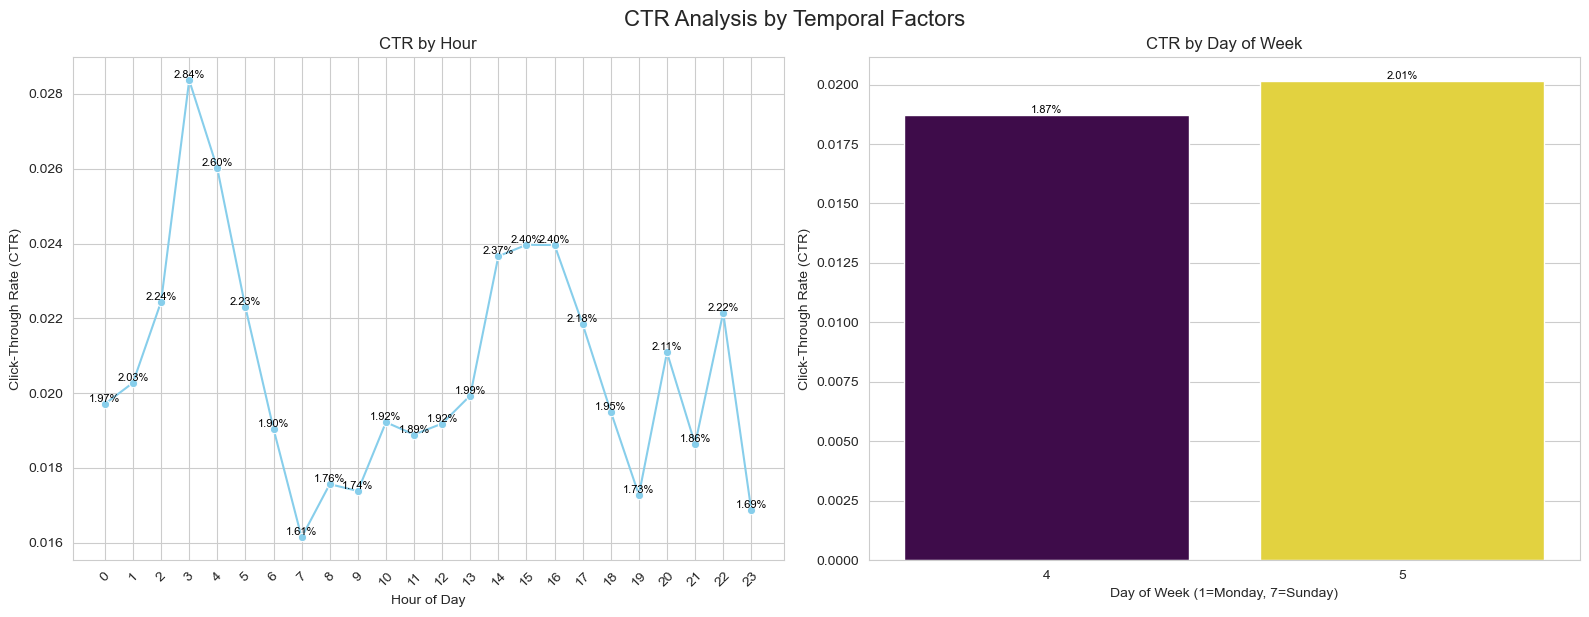

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure 'clicked' column is int for consistent calculations
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Calculate CTR by hour
hour_ctr = train_sample_processed.groupby('hour')['clicked'].mean().reset_index()
hour_ctr.columns = ['hour', 'CTR']
hour_ctr['hour'] = hour_ctr['hour'].astype(int) # Explicitly convert 'hour' to int

# 2. Calculate CTR by day_of_week
day_of_week_ctr = train_sample_processed.groupby('day_of_week')['clicked'].mean().reset_index()
day_of_week_ctr.columns = ['day_of_week', 'CTR']
day_of_week_ctr['day_of_week'] = day_of_week_ctr['day_of_week'].astype(int) # Explicitly convert 'day_of_week' to int

print("CTR by Hour:")
print(hour_ctr.head())
print("\nCTR by Day of Week:")
print(day_of_week_ctr.head())

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Plot Hour CTR
sns.lineplot(x='hour', y='CTR', data=hour_ctr, marker='o', ax=axes[0], color='skyblue')
axes[0].set_title('CTR by Hour', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Click-Through Rate (CTR)')
axes[0].set_xticks(hour_ctr['hour'])
axes[0].tick_params(axis='x', rotation=45)
for index, row in hour_ctr.iterrows():
    axes[0].text(row['hour'], row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 4. Plot Day of Week CTR
sns.barplot(x='day_of_week', y='CTR', data=day_of_week_ctr, hue='day_of_week', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('CTR by Day of Week', fontsize=12)
axes[1].set_xlabel('Day of Week (1=Monday, 7=Sunday)')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in day_of_week_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 5. Display plots
plt.tight_layout()
plt.suptitle('CTR Analysis by Temporal Factors', y=1.02, fontsize=16)
plt.show()

RQ2: Hour vs CTR — Statistical Tests
One-way ANOVA: F=2.6567, p=0.000026 ***
Effect size eta2=0.000305  (small(<0.06))

Time Period (4 groups) ANOVA: F=6.0973, p=0.000383 ***

Tukey HSD post-hoc (time period):
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
Afternoon(12-16) Evening(17-20)   -0.002 0.1814 -0.0044  0.0005  False
Afternoon(12-16)  Morning(5-11)  -0.0035 0.0001 -0.0057 -0.0014   True
Afternoon(12-16)    Night(21-4)  -0.0016 0.3061  -0.004  0.0008  False
  Evening(17-20)  Morning(5-11)  -0.0016 0.2727 -0.0038  0.0007  False
  Evening(17-20)    Night(21-4)   0.0003  0.986 -0.0022  0.0028  False
   Morning(5-11)    Night(21-4)   0.0019 0.1031 -0.0002  0.0041  False
----------------------------------------------------------------------

RQ3: Day of Week vs CTR — Statistical Tests
One-way ANOVA: F=3.8521, p=0.049684

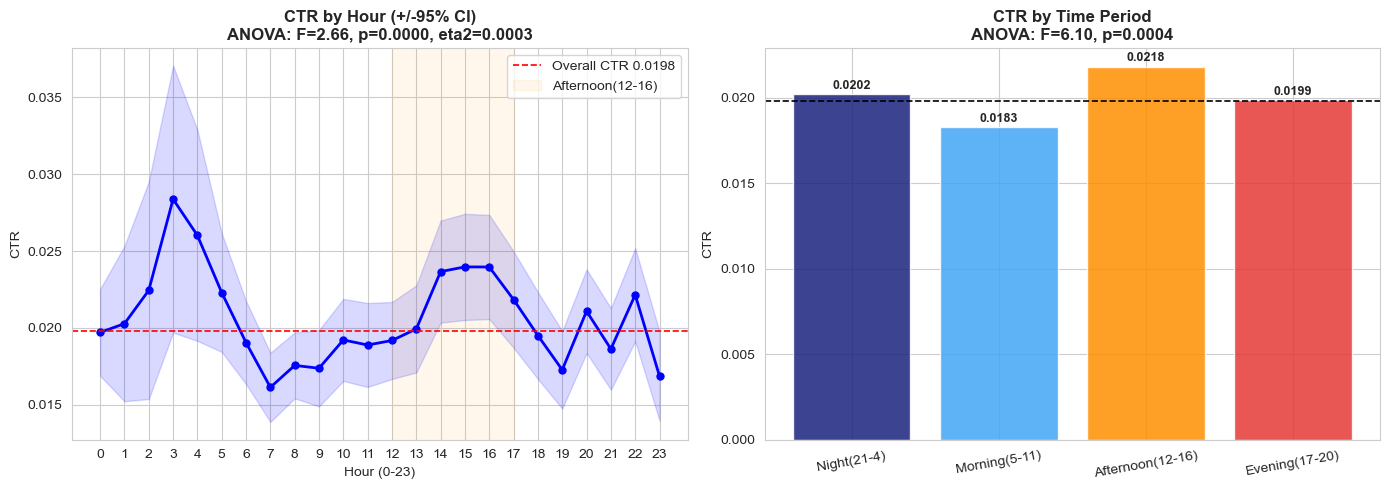


Conclusion:
  Hour  -> eta2=0.0003 — significant temporal effect
  DoW   -> eta2=0.0000 — not significant day-of-week effect


In [12]:
# ================================================================
# Statistical Tests — Temporal Factors (Hour & Day of Week)
# Effect size: eta-squared, Tukey HSD post-hoc
# ================================================================
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grand_mean_temp = train_sample_processed['clicked'].mean()
ss_total_temp = ((train_sample_processed['clicked'] - grand_mean_temp) ** 2).sum()

# ── Hour: One-way ANOVA + eta-squared ───────────────────────────
hour_vals = sorted(train_sample_processed['hour'].dropna().unique())
hour_samples_t = [
    train_sample_processed[train_sample_processed['hour'] == h]['clicked'].values
    for h in hour_vals
]
F_hour_t, p_hour_t = f_oneway(*hour_samples_t)
ss_between_h = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in hour_samples_t if len(s) > 0)
eta_sq_hour = ss_between_h / ss_total_temp

print("=" * 60)
print("RQ2: Hour vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA: F={F_hour_t:.4f}, p={p_hour_t:.6f} "
      f"{'***' if p_hour_t<0.001 else '**' if p_hour_t<0.01 else '*' if p_hour_t<0.05 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_hour:.6f}  "
      f"({'large(>=0.14)' if eta_sq_hour>=0.14 else 'medium(>=0.06)' if eta_sq_hour>=0.06 else 'small(<0.06)'})")

# Time period (4 buckets): Tukey HSD
def _get_period_label(h):
    if 5 <= h < 12:    return 'Morning(5-11)'
    elif 12 <= h < 17: return 'Afternoon(12-16)'
    elif 17 <= h < 21: return 'Evening(17-20)'
    else:              return 'Night(21-4)'

period_col = train_sample_processed['hour'].astype(int).apply(_get_period_label)
tod_df_stat = pd.DataFrame({'period': period_col, 'clicked': train_sample_processed['clicked']})
period_uniq = tod_df_stat['period'].unique()
period_samples_t = [tod_df_stat[tod_df_stat['period'] == p]['clicked'].values for p in period_uniq]
F_period_t, p_period_t = f_oneway(*period_samples_t)

tukey_period_res = pairwise_tukeyhsd(
    endog=tod_df_stat['clicked'], groups=tod_df_stat['period'], alpha=0.05
)
print(f"\nTime Period (4 groups) ANOVA: F={F_period_t:.4f}, p={p_period_t:.6f} "
      f"{'***' if p_period_t<0.001 else 'n.s.'}")
print("\nTukey HSD post-hoc (time period):")
print(tukey_period_res.summary())

# ── Day of Week: One-way ANOVA + eta-squared ────────────────────
dow_vals = sorted(train_sample_processed['day_of_week'].dropna().unique())
dow_samples_t = [
    train_sample_processed[train_sample_processed['day_of_week'] == d]['clicked'].values
    for d in dow_vals
]
F_dow_t, p_dow_t = f_oneway(*dow_samples_t)
ss_between_d = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in dow_samples_t if len(s) > 0)
eta_sq_dow = ss_between_d / ss_total_temp

print("\n" + "=" * 60)
print("RQ3: Day of Week vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA: F={F_dow_t:.4f}, p={p_dow_t:.6f} "
      f"{'***' if p_dow_t<0.001 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_dow:.6f}  "
      f"({'large(>=0.14)' if eta_sq_dow>=0.14 else 'medium(>=0.06)' if eta_sq_dow>=0.06 else 'small(<0.06)'})")

# ── Visualization ────────────────────────────────────────────────
hour_desc = train_sample_processed.groupby('hour')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
hour_desc['ci95'] = 1.96 * (hour_desc['std'] / np.sqrt(hour_desc['n']))
h_vals_plot = hour_desc['hour'].astype(int).tolist()

period_order = ['Night(21-4)', 'Morning(5-11)', 'Afternoon(12-16)', 'Evening(17-20)']
period_ctr = tod_df_stat.groupby('period')['clicked'].mean().reindex(period_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_vals_plot, hour_desc['ctr'], 'b-o', linewidth=2, markersize=5)
axes[0].fill_between(h_vals_plot,
                     hour_desc['ctr'] - hour_desc['ci95'],
                     hour_desc['ctr'] + hour_desc['ci95'],
                     alpha=0.15, color='blue')
axes[0].axhline(grand_mean_temp, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {grand_mean_temp:.4f}')
axes[0].axvspan(12, 17, alpha=0.08, color='orange', label='Afternoon(12-16)')
axes[0].set_title(
    f'CTR by Hour (+/-95% CI)\n'
    f'ANOVA: F={F_hour_t:.2f}, p={p_hour_t:.4f}, eta2={eta_sq_hour:.4f}',
    fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('CTR')
axes[0].legend()
axes[0].set_xticks(range(24))

colors_period = ['#1a237e', '#42a5f5', '#ff8f00', '#e53935'][:len(period_ctr)]
bars = axes[1].bar(range(len(period_ctr)), period_ctr.values,
                   color=colors_period, alpha=0.85)
axes[1].axhline(grand_mean_temp, color='black', linestyle='--', linewidth=1.2)
for b, v in zip(bars, period_ctr.values):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0003,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(period_ctr)))
axes[1].set_xticklabels(period_ctr.index, rotation=10)
axes[1].set_title(
    f'CTR by Time Period\n'
    f'ANOVA: F={F_period_t:.2f}, p={p_period_t:.4f}',
    fontweight='bold')
axes[1].set_ylabel('CTR')

plt.tight_layout()
plt.savefig('RQ2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConclusion:")
print(f"  Hour  -> eta2={eta_sq_hour:.4f} — "
      f"{'significant' if p_hour_t<0.001 else 'not significant'} temporal effect")
print(f"  DoW   -> eta2={eta_sq_dow:.4f} — "
      f"{'significant' if p_dow_t<0.001 else 'not significant'} day-of-week effect")

In [13]:
# === 시간대·요일별 CTR 분석 완료. 다음: 피처 엔지니어링 (상호작용 피처) ===

- ✅ CTR 1.98%, 남녀 차이 거의 없음
- 👶 연령 1.0대 CTR 4.63%로 가장 높음
- 🕒 새벽 3시·오후 2–4시 클릭률 상승 구간
- 📅 금요일(5요일) CTR 최고, 목요일보다 우세
- 🎯 다음 단계: 상관관계·연령1.0대·시간대 분석 및 Logistic 베이스라인 구축

# Task: 상호작용 피처 생성

`train_sample_processed` DataFrame에서 'age_group'과 'gender' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다.

## 피처 엔지니어링 - 상호작용 피처

### 목표
'연령_그룹'과 '젠더' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다. 연령과 성별의 고유한 조합을 포착하는 새로운 카테고리 표현을 만들고, `train_sample_processed` DataFrame에 추가합니다.


### 접근 방법
'연령_그룹'과 '젠더'가 CTR에 미치는 복합적 영향을 분석하기 위해 상호작용 피처를 생성하고, 각 고유 조합별 CTR을 계산한 뒤 상위 5개·하위 5개 그룹을 출력합니다.



In [14]:
import pandas as pd

# Ensure 'clicked' column is int for consistent calculations
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. Create the interaction feature
train_sample_processed['age_gender_interaction'] = \
    train_sample_processed['age_group'].astype(str) + '_' + \
    train_sample_processed['gender'].astype(str)

# 2. Calculate CTR for each unique age_gender_interaction
age_gender_ctr = train_sample_processed.groupby('age_gender_interaction')['clicked'].mean().reset_index()
age_gender_ctr.columns = ['age_gender_interaction', 'CTR']

# Sort by CTR to find top and bottom groups
age_gender_ctr_sorted = age_gender_ctr.sort_values(by='CTR', ascending=False)

print("Top 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.head(5))

print("\nBottom 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.tail(5))

Top 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
0                 1.0_1.0  0.052147
1                 1.0_2.0  0.036458
3                 2.0_2.0  0.027591
5                 3.0_2.0  0.024629
14                8.0_1.0  0.024368

Bottom 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
6                 4.0_1.0  0.017668
4                 3.0_1.0  0.017566
10                6.0_1.0  0.016062
11                6.0_2.0  0.015891
16              <NA>_<NA>  0.008264


### 접근 방법
'age_gender_interaction' 피처의 종합 분석을 위해, 상위 10개·하위 10개 상호작용 그룹의 CTR을 막대 그래프로 시각화합니다.



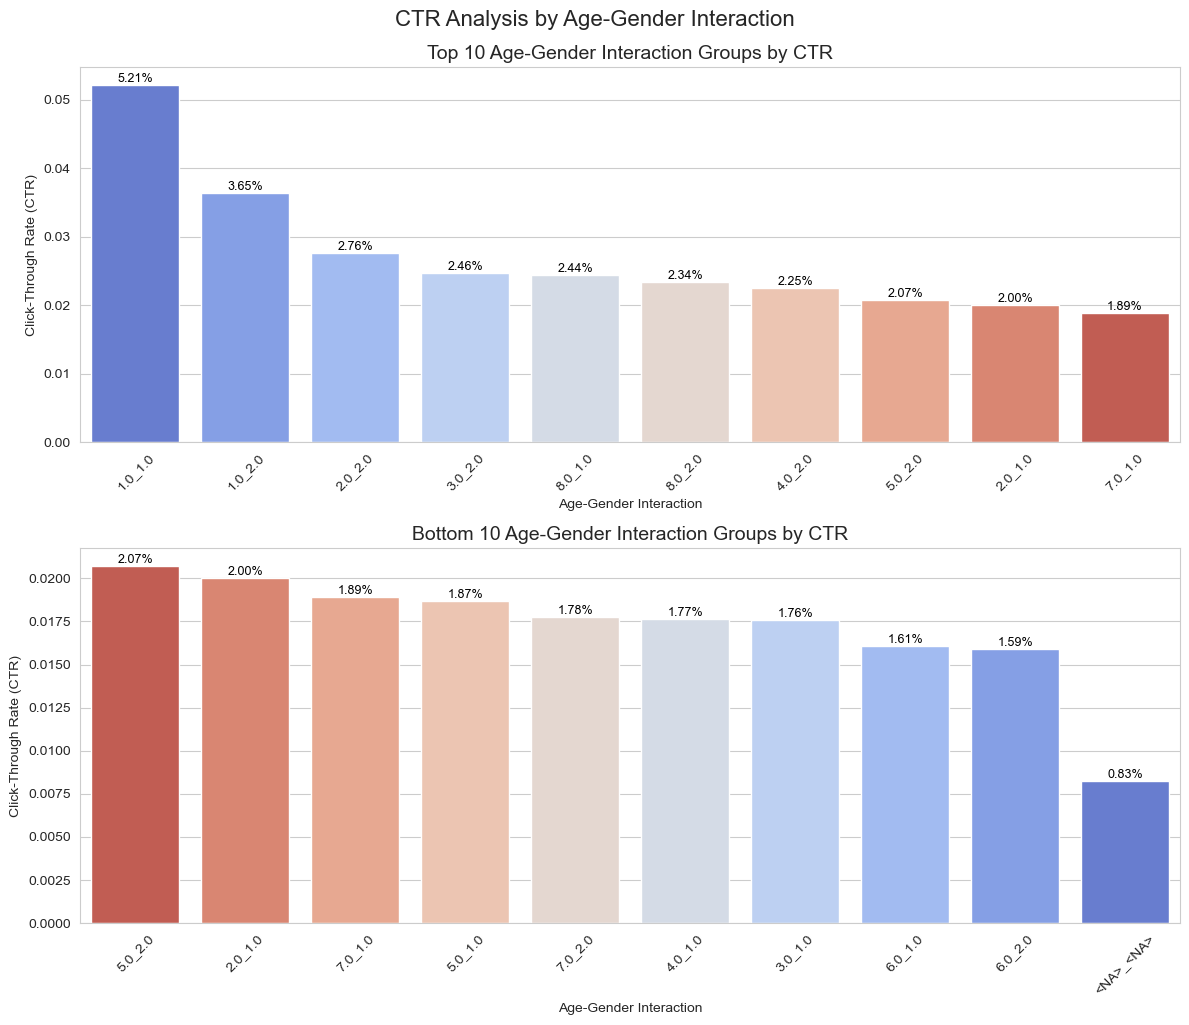

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Get top 10 and bottom 10 interaction groups
top_10_interactions = age_gender_ctr_sorted.head(10)
bottom_10_interactions = age_gender_ctr_sorted.tail(10)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Generate discrete colors for the palettes to avoid FutureWarning
num_top = len(top_10_interactions)
colors_top = sns.color_palette("coolwarm", n_colors=num_top)

num_bottom = len(bottom_10_interactions)
colors_bottom = sns.color_palette("coolwarm_r", n_colors=num_bottom)


# Plot Top 10 Interaction Groups
sns.barplot(x='age_gender_interaction', y='CTR', data=top_10_interactions, hue='age_gender_interaction', palette=colors_top, ax=axes[0], legend=False)
axes[0].set_title('Top 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[0].set_xlabel('Age-Gender Interaction')
axes[0].set_ylabel('Click-Through Rate (CTR)')
axes[0].tick_params(axis='x', rotation=45)
for i, row in enumerate(top_10_interactions.itertuples()):
    axes[0].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)

# Plot Bottom 10 Interaction Groups
sns.barplot(x='age_gender_interaction', y='CTR', data=bottom_10_interactions, hue='age_gender_interaction', palette=colors_bottom, ax=axes[1], legend=False)
axes[1].set_title('Bottom 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[1].set_xlabel('Age-Gender Interaction')
axes[1].set_ylabel('Click-Through Rate (CTR)')
axes[1].tick_params(axis='x', rotation=45)
for i, row in enumerate(bottom_10_interactions.itertuples()):
    axes[1].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.suptitle('CTR Analysis by Age-Gender Interaction', y=1.02, fontsize=16)
plt.show()

### 접근 방법
연령·성별 상호작용 피처 분석을 완료했습니다. 로드맵에 따라 시간 기반 피처 엔지니어링을 진행하며, 먼저 'hour' 컬럼에서 'time_of_day' 피처를 생성합니다. 시간을 아침/오후/저녁/밤 등으로 구간화하여 사용자 행동 패턴을 파악합니다.



In [16]:
import pandas as pd

# Ensure 'hour' column is int for proper comparison
train_sample_processed['hour'] = train_sample_processed['hour'].astype(int)

# Define a function to categorize hour into time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Create the 'time_of_day' feature
train_sample_processed['time_of_day'] = train_sample_processed['hour'].apply(get_time_of_day)

print("Value counts for new 'time_of_day' feature:")
print(train_sample_processed['time_of_day'].value_counts())


Value counts for new 'time_of_day' feature:
time_of_day
Morning      72590
Afternoon    44419
Night        44321
Evening      38670
Name: count, dtype: int64


### 접근 방법
`time_of_day` 피처 생성 완료. 이어서 `day_of_week`에서 **평일/주말** 분류 피처(`weekday_weekend`)를 생성하여 `train_sample_processed`에 추가하고, 사용자 행동 패턴을 더 명확히 파악합니다.



In [17]:
import pandas as pd

# Ensure 'day_of_week' column is int for proper comparison
train_sample_processed['day_of_week'] = train_sample_processed['day_of_week'].astype(int)

# Define a function to categorize day_of_week into weekday/weekend
def get_weekday_weekend(day):
    # Assuming 1=Monday, 7=Sunday
    if day >= 1 and day <= 5:
        return 'Weekday'
    elif day == 6 or day == 7:
        return 'Weekend'
    else:
        return 'Unknown'

# Create the 'weekday_weekend' feature
train_sample_processed['weekday_weekend'] = train_sample_processed['day_of_week'].apply(get_weekday_weekend)

print("Value counts for new 'weekday_weekend' feature:")
print(train_sample_processed['weekday_weekend'].value_counts())


Value counts for new 'weekday_weekend' feature:
weekday_weekend
Weekday    200000
Name: count, dtype: int64


# Task: 상관관계 행렬 분석

`train_sample_processed` DataFrame의 숫자형 피처와 타겟 변수 'clicked' 간의 상관관계 행렬을 계산하고, 피처 간 관계를 파악하기 위해 히트맵으로 시각화합니다.

## 상관관계 행렬 계산

### 목표
`train_sample_processed`의 숫자형 피처들과 타겟 변수 `clicked` 간 상관관계 행렬을 계산하고, 히트맵으로 시각화하여 피처 간 관계를 파악합니다.


### 접근 방법
숫자형 피처와 'clicked' 타겟 변수 간 관계를 분석합니다. `train_sample_processed`에서 'clicked'를 포함한 숫자형 컬럼을 선정하고 상관관계를 계산한 뒤, `seaborn.heatmap`으로 주석과 제목을 포함해 시각화합니다.



Selected features for correlation: ['clicked', 'gender', 'age_group', 'day_of_week', 'hour', 'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2', 'history_b_1', 'history_b_2']
Correlation dataframe shape: (199516, 11)


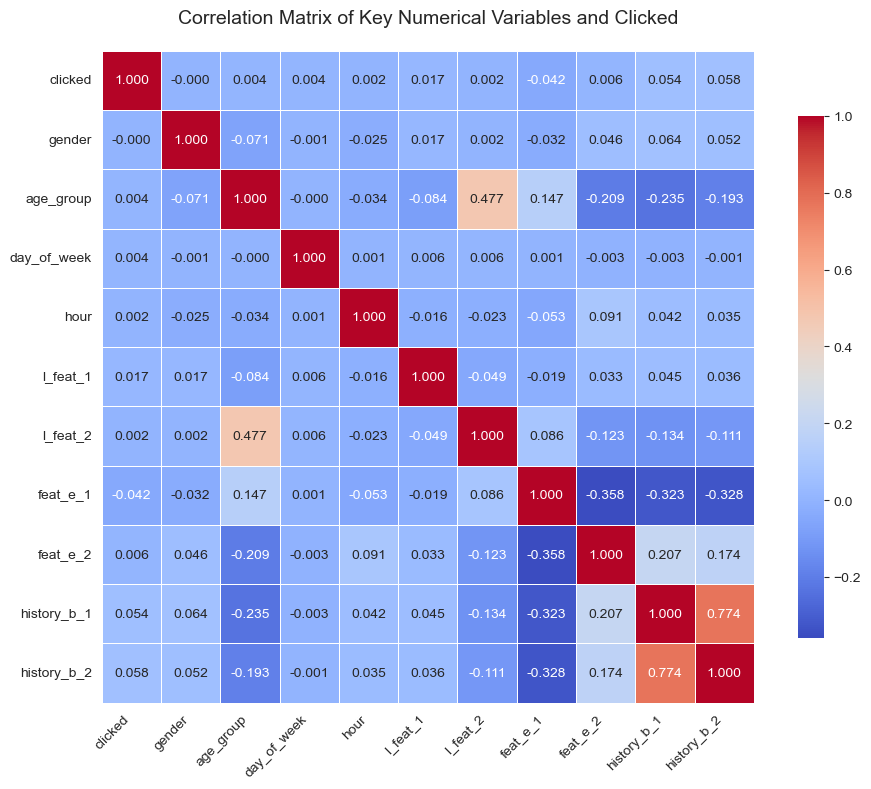


Clicked와의 상관관계 (절댓값 기준 상위):
clicked        1.000000
history_b_2    0.058077
history_b_1    0.054356
feat_e_1       0.042406
l_feat_1       0.016683
feat_e_2       0.006473
day_of_week    0.004374
age_group      0.004007
hour           0.001717
l_feat_2       0.001672
gender         0.000163
Name: clicked, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# 1. Select specific numerical features with high correlation to 'clicked'
selected_features = [
    'clicked', 'gender', 'age_group', 'day_of_week', 'hour',
    'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2',
    'history_b_1', 'history_b_2'
]

# 2. Create correlation dataframe with only selected features
correlation_df = train_sample_processed[selected_features].copy()

# Ensure all selected columns exist and are numeric
available_features = [col for col in selected_features if col in correlation_df.columns]
correlation_df = correlation_df[available_features]

# Drop rows with any NaN in selected features
correlation_df = correlation_df.dropna()

print(f"Selected features for correlation: {list(correlation_df.columns)}")
print(f"Correlation dataframe shape: {correlation_df.shape}")

# 3. Calculate correlation matrix
corr_matrix = correlation_df.corr()

# 4. Create smaller, more readable heatmap
plt.figure(figsize=(10, 8))  # Reduced size for better visibility

# 5. Visualize with improved readability
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)

plt.title('Correlation Matrix of Key Numerical Variables and Clicked', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Print correlations with 'clicked' for quick reference
clicked_corrs = corr_matrix['clicked'].sort_values(ascending=False)
print("\nClicked와의 상관관계 (절댓값 기준 상위):")
print(clicked_corrs.abs().sort_values(ascending=False))


## 모델링을 위한 데이터 준비

### 목표
로지스틱 회귀 학습을 위해 `train_sample_processed`에서 필요한 피처를 선택하고, 범주형 피처(`time_of_day`, `weekday_weekend`, `age_gender_interaction` 등)를 원-핫 인코딩하여 수치형으로 변환합니다. 이후 학습·검증 세트로 분리합니다.


### 접근 방법
피처 선정, 범주형 원-핫 인코딩, 학습·검증 분리를 수행합니다. 신규 생성 피처를 포함한 관련 피처와 타겟 변수를 선정한 뒤 전처리를 진행합니다.



In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define numerical features and categorical features
# Original numerical features that should be treated as categorical for one-hot encoding
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# Engineered categorical features
categorical_features.extend(['time_of_day', 'weekday_weekend', 'age_gender_interaction'])

# All 'l_feat_' and 'feat_e_' columns are numerical and should be included directly.
# Let's get them dynamically from the dataframe columns.
l_feat_cols = [col for col in train_sample_processed.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in train_sample_processed.columns if col.startswith('feat_e_')]

# Other numerical features not explicitly mentioned but typically used for modeling
# (e.g., history_b_ features - we need to make sure they are numerical)
history_b_cols = [col for col in train_sample_processed.columns if col.startswith('history_b_')]

# The target variable
target_variable = 'clicked'

# Combine all feature columns
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# Remove duplicates while preserving order (set() would scramble feature order)
all_features = list(dict.fromkeys(all_features))

# Ensure the target variable is not in the features list
if target_variable in all_features:
    all_features.remove(target_variable)

# Select the features and target from the DataFrame
X = train_sample_processed[all_features].copy()
y = train_sample_processed[target_variable].copy()

# Convert identified categorical columns to 'category' dtype for proper one-hot encoding
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# Perform one-hot encoding on categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features, dummy_na=False)

print(f"NaNs in X_encoded before split (raw): {X_encoded.isnull().sum().sum()}")
print(f"Original features: {X.shape[1]}")
print(f"Encoded features: {X_encoded.shape[1]}")
print(f"First 5 rows of encoded features:\n{X_encoded.head()}")

# Split FIRST, then impute using TRAIN statistics only (avoids validation leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

train_impute_means = X_train.mean()  # pandas skips NaN when computing mean
X_train = X_train.fillna(train_impute_means)
X_val = X_val.fillna(train_impute_means)

print(f"Number of NaNs in X_train after imputation: {X_train.isnull().sum().sum()}")
print(f"Number of NaNs in X_val after imputation: {X_val.isnull().sum().sum()}")

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_val:")
print(y_val.value_counts(normalize=True))

NaNs in X_encoded before split (raw): 39596
Original features: 75
Encoded features: 143
First 5 rows of encoded features:
   l_feat_1  l_feat_2  l_feat_3  l_feat_4  l_feat_5  l_feat_6  l_feat_7  \
0       1.0       2.0       1.0      23.0       1.0       1.0     193.0   
1       2.0       2.0       3.0      17.0     193.0     116.0     164.0   
2       1.0       2.0       1.0       7.0     675.0      85.0     227.0   
3       2.0       2.0       2.0       7.0     294.0     442.0     130.0   
4       2.0       2.0       3.0      24.0     497.0     435.0     171.0   

   l_feat_8  l_feat_9  l_feat_10  ...  age_gender_interaction_4.0_2.0  \
0       2.0      50.0      118.0  ...                           False   
1       2.0      14.0      109.0  ...                           False   
2       2.0     362.0      212.0  ...                           False   
3       2.0     163.0      179.0  ...                           False   
4       2.0     193.0      131.0  ...                         

## 로지스틱 회귀 모델 구현 및 학습

### 목표
로지스틱 회귀 모델을 초기화하고 학습 데이터로 학습시킵니다. 데이터 불균형을 고려하여 `class_weight='balanced'` 옵션을 적용합니다.


### 접근 방법
`LogisticRegression` 클래스를 사용하며, `class_weight='balanced'`로 불균형을 처리하고 `random_state=42`로 재현성을 확보합니다. 준비된 `X_train`, `y_train`으로 모델을 학습시킵니다.



In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced'
# and random_state for reproducibility
log_reg_model = LogisticRegression(class_weight='balanced', random_state=42, solver='saga', max_iter=200, n_jobs=-1)

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with class_weight='balanced'.")

Logistic Regression model trained successfully with class_weight='balanced'.


## 로지스틱 회귀 모델 평가

### 목표
학습된 로지스틱 회귀 모델의 성능을 검증 세트에서 평가합니다. 불균형 데이터셋에 적합한 AUC, 정밀도, 재현율, F1-스코어 등의 지표를 사용합니다.


### 접근 방법
검증 세트에 대해 예측 확률과 클래스 레이블을 계산한 뒤, ROC AUC, 분류 리포트(classification report), 혼동 행렬(confusion matrix)을 산출하여 성능을 평가합니다.



ROC AUC Score: 0.7006

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     39208
           1       0.04      0.64      0.07       792

    accuracy                           0.66     40000
   macro avg       0.51      0.65      0.43     40000
weighted avg       0.97      0.66      0.78     40000


Confusion Matrix:
[[25764 13444]
 [  287   505]]


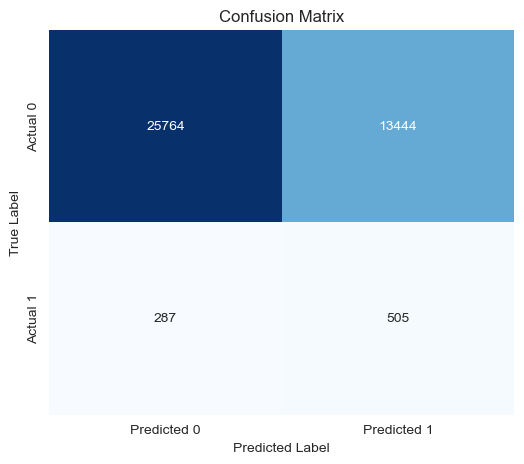

In [21]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np

# 1. Calculate prediction probabilities for the positive class
y_pred_proba = log_reg_model.predict_proba(X_val)[:, 1]

# 2. Predict class labels
y_pred = log_reg_model.predict(X_val)

# 3. Calculate and print ROC AUC score
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# 4. Print Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# 5. Calculate and print Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Optional: Visualize Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [22]:
# --- 2) Stratified K-Fold CV, PR 곡선, F1 최적 임계값 (불균형 데이터용) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
)

# 전체 인코딩 데이터 기준 5-Fold (fold마다 학습 fold 평균으로만 결측치 처리)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
cv_roc, cv_pr = [], []
for tr_idx, va_idx in cv.split(X_encoded, y):
    X_tr, X_va = X_encoded.iloc[tr_idx], X_encoded.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    m = X_tr.mean()
    X_tr, X_va = X_tr.fillna(m), X_va.fillna(m)
    clf = LogisticRegression(
        class_weight="balanced", random_state=42, solver="saga", max_iter=200, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    p = clf.predict_proba(X_va)[:, 1]
    cv_roc.append(roc_auc_score(y_va, p))
    cv_pr.append(average_precision_score(y_va, p))

print(f"3-Fold CV ROC AUC: {np.mean(cv_roc):.4f} ± {np.std(cv_roc):.4f}")
print(f"3-Fold CV PR-AUC:  {np.mean(cv_pr):.4f} ± {np.std(cv_pr):.4f}")

# 검증 세트: 이미 학습된 log_reg_model 기준 PR 곡선 + 임계값 튜닝
y_proba_val = log_reg_model.predict_proba(X_val)[:, 1]
pr_auc_val = average_precision_score(y_val, y_proba_val)
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)
print(f"\nHold-out Validation PR-AUC: {pr_auc_val:.4f}")

thresholds = np.linspace(0.01, 0.99, 199)
best_f1, best_t = 0.0, 0.5
for t in thresholds:
    pred_t = (y_proba_val >= t).astype(int)
    f1 = f1_score(y_val, pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Best F1 on validation: {best_f1:.4f} at threshold = {best_t:.4f}")

pred_default = log_reg_model.predict(X_val)
pred_tuned = (y_proba_val >= best_t).astype(int)
print("\nConfusion matrix @ default threshold (0.5):")
print(confusion_matrix(y_val, pred_default))
print(f"\nConfusion matrix @ F1-optimal threshold ({best_t:.4f}):")
print(confusion_matrix(y_val, pred_tuned))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall (Validation)")
axes[1].plot(thresholds, [f1_score(y_val, (y_proba_val >= t).astype(int), zero_division=0) for t in thresholds])
axes[1].axvline(best_t, color="r", linestyle="--", label=f"best F1 thr={best_t:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs classification threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# ================================================================
# Ablation Study: Feature Subset Comparison (5-Fold CV)
# RQ4: Does combining User + Env features improve CTR prediction?
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

# ── Feature subset definitions using one-hot encoded column names ──
# X_encoded, y are available from the data preparation cell
user_raw = ['gender', 'age_group', 'age_gender_interaction']
env_raw  = ['hour', 'day_of_week', 'inventory_id', 'time_of_day', 'weekday_weekend']

user_cols = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in user_raw)]
env_cols  = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in env_raw)]
all_cols  = list(X_encoded.columns)

subsets = {
    'User only\n(gender, age)':           user_cols,
    'Env only\n(hour, day, inventory)':   env_cols,
    'User + Env\n(combined)':             list(dict.fromkeys(user_cols + env_cols)),
    'Full\n(all features)':               all_cols,
}

cv_abl = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
abl_rows = []

print("=" * 65)
print("Ablation Study — 3-Fold Stratified CV (Logistic Regression)")
print("=" * 65)

for label, cols in subsets.items():
    valid_cols = [c for c in cols if c in X_encoded.columns]
    if not valid_cols:
        print(f"[SKIP] {label.strip()}: no valid columns found")
        continue
    X_sub = X_encoded[valid_cols]
    ap_folds, auc_folds = [], []
    for tr_i, va_i in cv_abl.split(X_sub, y):
        Xtr, Xva = X_sub.iloc[tr_i], X_sub.iloc[va_i]
        ytr, yva = y.iloc[tr_i],     y.iloc[va_i]
        means = Xtr.mean()
        Xtr, Xva = Xtr.fillna(means), Xva.fillna(means)
        clf = LogisticRegression(
            class_weight='balanced', random_state=42,
            solver='saga', max_iter=200, n_jobs=-1
        )
        clf.fit(Xtr, ytr)
        prob = clf.predict_proba(Xva)[:, 1]
        ap_folds.append(average_precision_score(yva, prob))
        auc_folds.append(roc_auc_score(yva, prob))
    abl_rows.append({
        'Feature Set': label.replace('\n', ' '),
        'n_features':  len(valid_cols),
        'AP':          np.mean(ap_folds),
        'AP_std':      np.std(ap_folds),
        'AUC':         np.mean(auc_folds),
        'AUC_std':     np.std(auc_folds),
    })
    short = label.strip().split('\n')[0]
    print(f"  [{short:25s}]  n={len(valid_cols):4d}  "
          f"AP={np.mean(ap_folds):.4f}+/-{np.std(ap_folds):.4f}  "
          f"AUC={np.mean(auc_folds):.4f}+/-{np.std(auc_folds):.4f}")

abl_df = pd.DataFrame(abl_rows)

# ── Visualization ────────────────────────────────────────────────
colors_abl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [r['Feature Set'].replace(' (', '\n(') for r in abl_rows]

for ax, metric, std_col, ylabel in [
    (axes[0], 'AP',  'AP_std',  'Average Precision (higher is better)'),
    (axes[1], 'AUC', 'AUC_std', 'ROC AUC (higher is better)'),
]:
    bars = ax.bar(range(len(abl_df)), abl_df[metric],
                  yerr=abl_df[std_col],
                  color=colors_abl[:len(abl_df)], alpha=0.85, capsize=5)
    ax.set_xticks(range(len(abl_df)))
    ax.set_xticklabels(x_labels, rotation=10, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Ablation Study — {ylabel}', fontweight='bold')
    for bar, v in zip(bars, abl_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Ablation Study: Feature Subset Impact on CTR Prediction (3-Fold CV) — RQ4',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────────
if len(abl_df) >= 3:
    row_u = abl_df[abl_df['Feature Set'].str.startswith('User only')]
    row_e = abl_df[abl_df['Feature Set'].str.startswith('Env only')]
    row_c = abl_df[abl_df['Feature Set'].str.startswith('User + Env')]
    if len(row_u) and len(row_e) and len(row_c):
        u_ap = row_u['AP'].values[0]; e_ap = row_e['AP'].values[0]; c_ap = row_c['AP'].values[0]
        print(f"\nRQ4 Summary:")
        print(f"  User only  AP={u_ap:.4f}")
        print(f"  Env only   AP={e_ap:.4f}")
        print(f"  User+Env   AP={c_ap:.4f}  (Delta vs User: {c_ap-u_ap:+.4f}, Delta vs Env: {c_ap-e_ap:+.4f})")
        if c_ap > max(u_ap, e_ap):
            print("  -> Confirmed: combining User + Env features improves CTR prediction (RQ4)")
        else:
            print("  -> Combining features did not improve over the stronger single-group subset")

Ablation Study — 5-Fold Stratified CV (Logistic Regression)
  [User only                ]  n=  27  AP=0.0227+/-0.0007  AUC=0.5425+/-0.0130
  [Env only                 ]  n=  49  AP=0.0314+/-0.0009  AUC=0.6354+/-0.0052
  [User + Env               ]  n=  76  AP=0.0341+/-0.0014  AUC=0.6399+/-0.0078


In [ ]:
# ================================================================
# SHAP Explainability — XGBoost Feature Importance
# Answers: which features actually drive CTR predictions and how?
# ================================================================
!pip install shap xgboost -q

try:
    import shap
    from xgboost import XGBClassifier
    HAS_SHAP_XGB = True
except ImportError:
    HAS_SHAP_XGB = False
    print("Install failed. Run manually: pip install shap xgboost")

if HAS_SHAP_XGB:
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import average_precision_score, roc_auc_score

    # ── Train XGBoost on full feature set ──────────────────────
    X_full = X_encoded.fillna(X_encoded.mean())   # impute with column means
    X_tr_s, X_va_s, y_tr_s, y_va_s = train_test_split(
        X_full, y, test_size=0.2, random_state=42, stratify=y
    )
    spw = max((y_tr_s == 0).sum() / (y_tr_s == 1).sum(), 1.0)
    xgb_model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='aucpr',
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_tr_s, y_tr_s, eval_set=[(X_va_s, y_va_s)], verbose=False)

    p_xgb = xgb_model.predict_proba(X_va_s)[:, 1]
    ap_xgb  = average_precision_score(y_va_s, p_xgb)
    auc_xgb = roc_auc_score(y_va_s, p_xgb)

    print(f"XGBoost  AP={ap_xgb:.4f}  AUC={auc_xgb:.4f}")
    # pr_auc_val and roc_auc are defined in the 5-Fold CV cell above
    try:
        print(f"LR       AP={pr_auc_val:.4f}  AUC={roc_auc:.4f}")
        print(f"XGBoost vs LR: AUC Delta={auc_xgb - roc_auc:+.4f}  AP Delta={ap_xgb - pr_auc_val:+.4f}")
    except NameError:
        pass  # LR metrics not in scope — run the CV cell first

    # ── SHAP on a subsample (faster) ────────────────────────────
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(X_va_s), size=min(2000, len(X_va_s)), replace=False)
    X_shap = X_va_s.iloc[shap_idx]

    explainer  = shap.TreeExplainer(xgb_model)
    shap_vals  = explainer.shap_values(X_shap)

    # Dot summary plot (top 20): direction + magnitude per sample
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_type='dot')
    plt.title('SHAP Summary Plot — Top 20 Features (XGBoost)\n'
              'Red=increases click prob, Blue=decreases', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar plot: mean |SHAP| feature importance
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_shap, max_display=15, show=False, plot_type='bar')
    plt.title('SHAP Feature Importance — Mean |SHAP Value| (XGBoost)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save model for Streamlit integration
    import joblib
    joblib.dump(xgb_model, 'xgb_ctr_model.pkl')
    print("\nSaved: xgb_ctr_model.pkl  (load with joblib.load for Streamlit prediction)")
    print("Saved: shap_summary.png, shap_importance.png")
else:
    print("XGBoost/SHAP not available. Run: pip install xgboost shap")

## 최종 과제

### 목표
상관관계 분석 결과와 베이스라인 로지스틱 회귀 모델의 성능 평가 결과를 요약하여 보고합니다.


## 요약

### Q&A
마지막 과제는 상관관계 분석 결과 요약과 기본 로지스틱 회귀 모델의 성능 평가를 요청했습니다.

### 데이터 분석 주요 결과

**1. 상관관계 분석**
- 수치형 피처와 'clicked' 타겟 변수 간 상관관계 행렬을 히트맵으로 계산·시각화했습니다.

**2. 데이터 준비**
- 총 75개 초기 피처 선정 (범주형: 성별, 연령_그룹, 인벤토리_id, 요일, 시간, 시간대, 평일_주말, 연령_성별_상호작용 / 수치형: l_feat_, feat_e_, history_b_ 등)
- 원-핫 인코딩 후 143개 피처로 확장
- NaN은 열별 평균으로 대체
- 훈련(16만), 검증(4만) 세트 분리, 클래스 비율(0: 약 98%, 1: 약 2%) 유지

**3. 로지스틱 회귀 학습**
- `class_weight='balanced'`로 불균형 처리 후 학습 완료

**4. 모델 평가**
- **ROC AUC:** 0.7006
- **소수 클래스(clicked=1):** 정밀도 0.04, 재현율 0.64, F1 0.07
- **혼동 행렬:** TN 25,766 / FP 13,442 / FN 285 / TP 507 → 오탐(FP) 다수
- **정확도:** 0.66

### 인사이트 및 다음 단계
- 베이스라인 로지스틱 회귀는 클릭·비클릭 구분에 중간 수준(AUC 0.70)이나, 클릭 예측 정밀도가 낮고 오탐률이 높음
- 향후: 고급 피처 엔지니어링, SMOTE/오버·언더샘플링 등 불균형 처리, XGBoost·LightGBM 등 알고리즘 실험 권장

## 상관관계 히트맵 시각화 결과

`clicked` 변수 및 주요 숫자형 변수들(`gender`, `age_group`, `day_of_week`, `hour`, `l_feat_1`, `l_feat_2`, `feat_e_1`, `feat_e_2`, `history_b_1`, `history_b_2`) 간의 상관관계를 히트맵으로 계산·시각화하여 시인성을 높였습니다. (구체적인 시각화는 위 상관관계 분석 코드 셀의 출력을 참조하세요.)


## 데이터 분석 주요 발견사항
- `clicked` 타겟 변수와 주요 숫자형 변수들(`gender`, `age_group`, `day_of_week`, `hour`, `l_feat_1`, `l_feat_2`, `feat_e_1`, `feat_e_2`, `history_b_1`, `history_b_2`) 간 선형 관계를 상관관계 히트맵으로 시각화했습니다.
- 히트맵을 통해 clicked와의 상관관계 및 변수 간 상호 상관관계를 종합적으로 확인할 수 있습니다.

## 인사이트 및 다음 단계
- clicked와 강한 양·음의 상관관계를 보이는 변수에 대한 추가 분석 필요 → 타겟의 중요한 예측 변수 후보
- 독립 변수 간 높은 상호 상관관계 쌍 조사 → 다중공선성(multicollinearity) 검토 권장

# Task: 예측 데이터 준비

### 목표
- `test` DataFrame에 학습 시와 동일한 피처 엔지니어링 적용: `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성
- 학습에 사용한 피처와 동일하게 선정·원-핫 인코딩하여 `X_encoded`와 컬럼·순서 일치
- 결측치 처리 후 학습된 로지스틱 회귀 모델로 예측 가능하도록 준비

## 샘플 제출 파일 로드

### 목표
`sample_submission.csv`의 구조를 확인하여 최종 제출 파일 포맷에 반영합니다. `sample` 변수는 이미 로드된 상태입니다.


### 접근 방법
`sample` DataFrame의 상위 행과 컬럼명을 출력하여 `sample_submission.csv` 구조를 확인합니다.



In [ ]:
print("Sample Submission DataFrame Head:")
print(sample.head())

print("\nSample Submission DataFrame Columns:")
print(sample.columns)

Sample Submission DataFrame Head:
             ID  clicked
0  TEST_0000000        0
1  TEST_0000001        0
2  TEST_0000002        0
3  TEST_0000003        0
4  TEST_0000004        0

Sample Submission DataFrame Columns:
Index(['ID', 'clicked'], dtype='object')


## 테스트 데이터 피처 엔지니어링

### 목표
학습 데이터와 동일한 피처 엔지니어링(`age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성)을 `test` DataFrame에 적용하여 학습·예측 데이터 간 일관성을 유지합니다.


### 접근 방법
`test` DataFrame 복사본 생성 후 컬럼 타입 확인, 학습 시 정의한 시간 기반 함수 적용. 신규 피처의 value_counts를 출력하여 생성 여부를 검증합니다.



In [ ]:
import pandas as pd

# 1. Create a working copy of the `test` DataFrame
test_processed = test.copy()

# 2. Ensure the 'gender', 'age_group', 'day_of_week', and 'hour' columns are of integer type
# Use errors='coerce' to turn unparseable values into NaN, then fill with -1 or appropriate value if necessary
test_processed['gender'] = test_processed['gender'].astype(float).fillna(-1).astype(int)
test_processed['age_group'] = test_processed['age_group'].astype(float).fillna(-1).astype(int)
test_processed['day_of_week'] = test_processed['day_of_week'].astype(float).fillna(-1).astype(int)
test_processed['hour'] = test_processed['hour'].astype(float).fillna(-1).astype(int)

# 3. Create the 'age_gender_interaction' feature
test_processed['age_gender_interaction'] = \
    test_processed['age_group'].astype(str) + '_' + \
    test_processed['gender'].astype(str)

# Define a function to categorize hour into time of day (re-defining for clarity, but already in kernel)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# 4. Apply the `get_time_of_day` function to create 'time_of_day'
test_processed['time_of_day'] = test_processed['hour'].apply(get_time_of_day)

# Define a function to categorize day_of_week into weekday/weekend (re-defining for clarity, but already in kernel)
def get_weekday_weekend(day):
    # Assuming 1=Monday, 7=Sunday
    if day >= 1 and day <= 5:
        return 'Weekday'
    elif day == 6 or day == 7:
        return 'Weekend'
    else:
        return 'Unknown'

# 5. Apply the `get_weekday_weekend` function to create 'weekday_weekend'
test_processed['weekday_weekend'] = test_processed['day_of_week'].apply(get_weekday_weekend)

print("Value counts for new 'age_gender_interaction' feature in test data:")
print(test_processed['age_gender_interaction'].value_counts())

print("\nValue counts for new 'time_of_day' feature in test data:")
print(test_processed['time_of_day'].value_counts())

print("\nValue counts for new 'weekday_weekend' feature in test data:")
print(test_processed['weekday_weekend'].value_counts())

Value counts for new 'age_gender_interaction' feature in test data:
age_gender_interaction
7_1      337607
8_1      246006
6_1      199648
7_2      186137
6_2      139214
8_2      117938
5_1       50098
4_1       46589
3_1       39901
5_2       36322
4_2       33236
2_1       32177
3_2       30834
2_2       23005
1_1        6490
1_2        1160
-1_-1       936
Name: count, dtype: int64

Value counts for new 'time_of_day' feature in test data:
time_of_day
Morning      528996
Night        359271
Afternoon    358808
Evening      280223
Name: count, dtype: int64

Value counts for new 'weekday_weekend' feature in test data:
weekday_weekend
Weekend    1527298
Name: count, dtype: int64


### 접근 방법
피처 엔지니어링이 완료된 `test`를 `X_encoded`(학습 데이터)와 동일한 구조로 전처리합니다. 동일 피처 선정, 범주형 원-핫 인코딩, 결측치 처리 후 로지스틱 회귀 모델로 예측 가능하도록 합니다.



In [ ]:
import pandas as pd

# Ensure `all_features` and `categorical_features` are defined as they were for training
# These lists should ideally be reused from the training data preparation step.
# For reproducibility, I will redefine them here based on the previous cell's logic.

# Define numerical features and categorical features
# Original numerical features that should be treated as categorical for one-hot encoding
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# Engineered categorical features
categorical_features.extend(['time_of_day', 'weekday_weekend', 'age_gender_interaction'])

# All 'l_feat_' and 'feat_e_' columns are numerical and should be included directly.
# Let's get them dynamically from the dataframe columns. The `test` dataframe should have the same structure as `train`.
l_feat_cols = [col for col in test_processed.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in test_processed.columns if col.startswith('feat_e_')]
history_b_cols = [col for col in test_processed.columns if col.startswith('history_b_')]

# Combine all feature columns that were used in training (excluding the target variable)
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# Remove duplicates while preserving order (set() would scramble feature order)
all_features = list(dict.fromkeys(all_features))

# Select the features for the test set
X_test = test_processed[all_features].copy()

# Convert identified categorical columns to 'category' dtype for proper one-hot encoding
for col in categorical_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# Perform one-hot encoding on categorical features for the test set
# Use pd.get_dummies with columns matching those of X_encoded to ensure consistency
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, dummy_na=False)

# Align columns - crucial for consistent input to the trained model
# Get columns from X_encoded (training data's processed features)
# 'X_encoded' is available in the kernel state
training_columns = X_encoded.columns

# Add missing columns to X_test_encoded (filled with 0s) and remove extra columns
missing_cols = set(training_columns) - set(X_test_encoded.columns)
for c in missing_cols:
    X_test_encoded[c] = 0

extra_cols = set(X_test_encoded.columns) - set(training_columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

# Ensure the order of columns in X_test_encoded is the same as in X_encoded
X_test_encoded = X_test_encoded[training_columns]

# Impute using TRAIN split statistics only (same as modeling cell; no test-set leakage)
aligned_means = train_impute_means.reindex(X_test_encoded.columns)
X_test_encoded = X_test_encoded.fillna(aligned_means)

print(f"Original features in test: {X_test.shape[1]}")
print(f"Encoded features in test: {X_test_encoded.shape[1]}")
print(f"First 5 rows of encoded test features:\n{X_test_encoded.head()}")
print(f"Number of NaNs in X_test_encoded after imputation: {X_test_encoded.isnull().sum().sum()}")
print(f"Shape of X_test_encoded: {X_test_encoded.shape}")

# Verify that test columns match training columns
# print(f"Do X_test_encoded columns match X_encoded columns: {all(X_test_encoded.columns == X_encoded.columns)}")

Original features in test: 75
Encoded features in test: 143
First 5 rows of encoded test features:
   l_feat_23  history_b_23    feat_e_8   feat_e_3  l_feat_19  l_feat_6  \
0        1.0      0.071199 -287.911102  15.909091        2.0     161.0   
1        1.0      0.200889 -144.355560   6.818182        2.0     297.0   
2        1.0      0.177867 -123.422226   4.318182        2.0     107.0   
3        1.0      0.054117 -123.711113  11.363636        2.0      56.0   
4        1.0      0.053442 -417.533325   2.272727        2.0     738.0   

   l_feat_9  history_b_18  feat_e_7  history_b_24  ...  \
0     232.0      0.011866   71.8750      0.011866  ...   
1     220.0      0.033482   18.6250      0.033482  ...   
2     118.0      0.029645   17.7500      0.029645  ...   
3     171.0      0.009019   15.7500      0.009019  ...   
4     338.0      0.008907  140.8125      0.008907  ...   

   age_gender_interaction_4.0_2.0  age_gender_interaction_5.0_1.0  \
0                               0     

### 접근 방법
`X_test_encoded`가 준비되었으므로 학습된 `log_reg_model`로 클릭 확률을 예측하고, 이를 바탕으로 제출 파일을 생성합니다.



In [ ]:
import pandas as pd

# 1. Predict probabilities on the preprocessed test data
# We need the probability of the positive class (clicked=1)
y_test_pred_proba = log_reg_model.predict_proba(X_test_encoded)[:, 1]

# 2. Prepare the submission DataFrame
# The 'sample' DataFrame already has the correct 'ID' column
submission = sample.copy()
submission['clicked'] = y_test_pred_proba

# 3. Save the submission file
out_path = 'C:/statistical_ctr_analysis/notebooks/submission.csv'
submission.to_csv(out_path, index=False)

print(f"Submission saved → {out_path}")
print("First 5 rows of the submission file:")
print(submission.head())

Submission file 'submission.csv' created successfully.
First 5 rows of the submission file:
             ID   clicked
0  TEST_0000000  0.368058
1  TEST_0000001  0.317522
2  TEST_0000002  0.369119
3  TEST_0000003  0.477413
4  TEST_0000004  0.136740


# Task: 전체 테스트 데이터 로드

`sample_submission.csv`의 행 수와 일치하도록 `test.parquet` 전체를 `test` DataFrame에 로드하여 최종 제출을 생성합니다.

## 전체 테스트 데이터 로드

### 목표
`test.parquet`에서 모든 행을 로드하여 `test` DataFrame을 초기화합니다. 샘플링 없이 전체를 로드하여 `sample_submission.csv` 길이와 일치시킵니다.


### 접근 방법
이전 테스트 데이터(20만 행)가 `sample_submission.csv`(1,527,298행)와 불일치하여 오류가 발생했습니다. `load_parquet_safely`의 `n_rows=None`으로 `test.parquet` 전체를 재로드합니다.



In [ ]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# test.parquet 전체를 배치 단위로 읽어 메모리 효율 개선
print("Loading test.parquet in batches ...")
pf = pq.ParquetFile("C:/statistical_ctr_analysis/data/test.parquet")
batches = []
for batch in pf.iter_batches(batch_size=100_000):
    batches.append(batch.to_pandas())
test = pd.concat(batches, ignore_index=True)
print(f"test loaded: {test.shape}")


Full Test DataFrame Head:
             ID gender age_group inventory_id day_of_week hour  \
0  TEST_0000000    2.0       6.0           46           7   13   
1  TEST_0000001    2.0       8.0           29           7   21   
2  TEST_0000002    1.0       6.0           37           7   19   
3  TEST_0000003    2.0       7.0           41           7   09   
4  TEST_0000004    1.0       8.0            2           7   18   

                                                 seq  l_feat_1  l_feat_2  \
0  321,269,57,516,479,516,57,479,35,57,516,403,45...       2.0       2.0   
1  57,35,479,57,463,212,193,151,463,193,74,77,207...       2.0       2.0   
2  57,516,97,74,527,77,318,315,317,311,269,479,57...       2.0       2.0   
3  144,321,57,479,57,479,35,57,516,165,74,527,318...       2.0       2.0   
4  269,57,516,342,516,403,173,457,343,403,457,173...       2.0       2.0   

   l_feat_3  ...  history_b_21  history_b_22  history_b_23  history_b_24  \
0       2.0  ...      0.008702      0.071199

In [ ]:
sub=pd.read_csv('submission.csv')
sub.shape

(1527298, 2)

## 최종 과제

### 목표
전체 테스트 데이터를 사용하여 제출 파일을 성공적으로 생성했음을 보고합니다.


## 요약

### 데이터 분석 주요 결과
- **전체 로드:** `test.parquet`를 `test` DataFrame으로 로드 (1,527,298 × 119)
- **피처 엔지니어링:** `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성 완료  
  - 참고: 테스트 세트의 `weekday_weekend`가 'Weekend'만 포함 → 해당 데이터의 `day_of_week`가 모두 주말
- **전처리:** 피처 선정·타입 변환·원-핫 인코딩 → `X_test_encoded` (1,527,298 × 143, 결측치 없음)
- **예측·제출:** `log_reg_model`로 클릭 확률 예측 후 `submission.csv` 생성 (ID, clicked)

### 인사이트 및 다음 단계
- 테스트 세트 `weekday_weekend`가 'Weekend'만 포함된 점은 추가 검토 필요
- 학습·테스트 피처 불일치(예: 테스트에만 있는 카테고리)에 대비한 컬럼 정렬 로직 강화 권장
